# Gradient descent: curvature, step size, and stopping

**Objective.** Use the package optimizer on a convex quadratic whose optimum is known,
show how learning rate changes convergence, and validate the result as a least-squares problem.

## Reproducible setup

Install the package from the repository root with `python -m pip install -e ".[dev]"`,
then select a kernel from that environment. Run all cells from top to bottom.
The algorithm is imported from `ml_from_scratch`; this notebook contains only the experiment.
All data are bundled with scikit-learn or generated locally, with seed 42.

## Mathematical intuition

Gradient descent updates parameters through
$$\theta_{t+1}=\theta_t-\alpha\nabla J(\theta_t).$$
Here $J(\theta)=\frac12(\theta-\theta^*)^T H(\theta-\theta^*)$,
$H=\operatorname{diag}(1,9)$, and $\theta^*=(2,-1)$.
The gradient is $H(\theta-\theta^*)$. The largest curvature is 9, so fixed steps
$0<\alpha<2/9$ converge for this quadratic. Being close to the upper bound can cause
oscillation in the steep direction even while the objective decreases.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression as ReferenceLinearRegression

from ml_from_scratch import GradientDescent

curvature = np.array([1.0, 9.0])
optimum = np.array([2.0, -1.0])
initial = np.array([-4.0, 4.0])


def objective(parameters):
    displacement = parameters - optimum
    return float(0.5 * np.sum(curvature * displacement**2)), curvature * displacement

## Use the reusable optimizer

This function is the experiment's objective, not a copy of the optimizer. It returns the
scalar loss and its gradient. `loss_history_` includes the initial loss; `n_iter_` counts
accepted parameter updates. The optimizer stops when the gradient norm is at most `tol`.

In [2]:
optimizers = {}
for learning_rate in (0.02, 0.1, 0.21):
    optimizer = GradientDescent(learning_rate=learning_rate, max_iter=2000, tol=1e-9)
    optimizer.minimize(objective, initial)
    optimizers[learning_rate] = optimizer
    loss, gradient = objective(optimizer.params_)
    print(
        f"alpha={learning_rate:.2f}  updates={optimizer.n_iter_:4d}  "
        f"converged={optimizer.converged_}  loss={loss:.2e}  "
        f"gradient_norm={np.linalg.norm(gradient):.2e}"
    )

alpha=0.02  updates=1115  converged=True  loss=4.89e-19  gradient_norm=9.89e-10
alpha=0.10  updates= 214  converged=True  loss=4.69e-19  gradient_norm=9.68e-10
alpha=0.21  updates= 211  converged=True  loss=4.94e-20  gradient_norm=9.43e-10


## Independent reference through least squares

Write $A=\operatorname{diag}(1,3)$ and $b=A\theta^*$. Then
$J(\theta)=\frac12\|A\theta-b\|^2$ is the same objective. scikit-learn's
`LinearRegression(fit_intercept=False)` solves for its coefficients directly. This gives
an independent numerical reference without pretending scikit-learn exposes this optimizer API.

In [3]:
design = np.diag(np.sqrt(curvature))
target = design @ optimum
reference = ReferenceLinearRegression(fit_intercept=False).fit(design, target)
result = optimizers[0.1]
print("Analytic optimum:", optimum)
print("Gradient descent:", result.params_)
print("Reference coefficients:", reference.coef_)
print(f"Parameter distance to reference: {np.linalg.norm(result.params_ - reference.coef_):.3e}")

Analytic optimum: [ 2. -1.]
Gradient descent: [ 2. -1.]
Reference coefficients: [ 2. -1.]
Parameter distance to reference: 9.684e-10


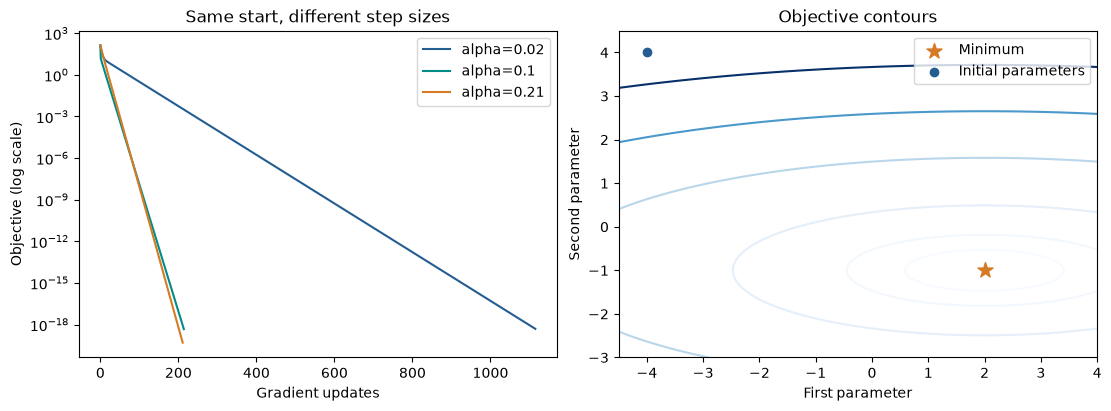

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for (learning_rate, optimizer), color in zip(
    optimizers.items(), ["#245d91", "#008c87", "#d57a25"], strict=True
):
    axes[0].semilogy(
        np.maximum(optimizer.loss_history_, 1e-22), color=color, label=f"alpha={learning_rate}"
    )
axes[0].set(
    xlabel="Gradient updates",
    ylabel="Objective (log scale)",
    title="Same start, different step sizes",
)
axes[0].legend()
horizontal, vertical = np.meshgrid(np.linspace(-4.5, 4, 150), np.linspace(-3, 4.5, 150))
values = 0.5 * ((horizontal - 2) ** 2 + 9 * (vertical + 1) ** 2)
axes[1].contour(horizontal, vertical, values, levels=[1, 3, 10, 30, 60, 100], cmap="Blues")
axes[1].scatter(*optimum, color="#d57a25", marker="*", s=130, label="Minimum")
axes[1].scatter(*initial, color="#245d91", label="Initial parameters")
axes[1].set(xlabel="First parameter", ylabel="Second parameter", title="Objective contours")
axes[1].legend()
plt.show()

## Conclusion

Curvature determines the range of stable step sizes, and conditioning determines how
differently the coordinates converge. The printed gradient norms verify the actual stopping
condition. The loss at update zero also makes histories interpretable across learning rates.

The core optimizer raises a useful error when a step materially increases the objective
or produces non-finite arithmetic. It warns when the iteration limit is reached. This
explicit fixed-step design keeps numerical behavior visible; it has no line search,
momentum, mini-batches, or automatic learning-rate schedule. Linear and logistic regression
reuse the same optimizer. See [the mathematics](../docs/mathematics.md).